# 🔭 Common Test I: Multi-Class Classification
## GSoC 2026 — ML4SCI DeepLense Project

**Objective:** Classify simulated astronomical images into three categories:
1. `no` (No Substructure)
2. `sphere` (Subhalo Substructure)
3. `vort` (Vortex Substructure)

**Strategy:** - Implement a custom PyTorch Dataset with on-the-fly Data Augmentation.
- Train two models (**ResNet18** and **EfficientNet-B0**) for 10 epochs each.
- Evaluate using Macro-Average One-vs-Rest (OvR) ROC AUC.

In [1]:
import os
import zipfile
import shutil
import time
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models

from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.preprocessing import label_binarize

# 1. Set Seed for Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)

# 2. Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Setup Complete. Using device: {device}")

✅ Setup Complete. Using device: cuda


In [3]:
from google.colab import drive
drive.mount('/content/drive')

# Paths
zip_path = '/content/drive/MyDrive/Colab Notebooks/GSoC2026/ dataset.zip'
extract_path = '/content/common_test_data'

# Extract
os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset extracted successfully!


## 1. Data Pipeline & Loaders
Loading the `.npy` files, converting single-channel arrays to 3-channels (for pretrained models), and applying transformations.

In [4]:
# Classes based on extracted folders
CLASSES = {'no': 0, 'sphere': 1, 'vort': 2}
NUM_CLASSES = len(CLASSES)

class LensingMultiClassDataset(Dataset):
    def __init__(self, data_dir, augment=False):
        self.files = []
        self.labels = []
        self.augment = augment

        for class_name, label in CLASSES.items():
            class_dir = os.path.join(data_dir, class_name)
            if os.path.exists(class_dir):
                for f in os.listdir(class_dir):
                    if f.endswith('.npy'):
                        self.files.append(os.path.join(class_dir, f))
                        self.labels.append(label)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img = np.load(self.files[idx]).astype(np.float32)

        # Ensure 3 channels
        if len(img.shape) == 2:
            img = np.stack((img,)*3, axis=0)
        elif len(img.shape) == 3 and img.shape[0] == 1:
            img = np.repeat(img, 3, axis=0)

        label = self.labels[idx]

        # Data Augmentation
        if self.augment:
            if np.random.rand() > 0.5: img = img[:, :, ::-1].copy() # H-Flip
            if np.random.rand() > 0.5: img = img[:, ::-1, :].copy() # V-Flip
            k = np.random.randint(4)
            img = np.rot90(img, k, axes=(1,2)).copy() # Rotation

        return torch.tensor(img), torch.tensor(label, dtype=torch.long)

# Initialize Loaders
base_dir = '/content/common_test_data/dataset'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')

train_dataset = LensingMultiClassDataset(train_dir, augment=True)
val_dataset = LensingMultiClassDataset(val_dir, augment=False)

BATCH_SIZE = 128 # 128 is faster, optimal for 64x64 images
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"✅ DataLoaders Ready! Train: {len(train_dataset)} images | Val: {len(val_dataset)} images.")

✅ DataLoaders Ready! Train: 30000 images | Val: 7500 images.


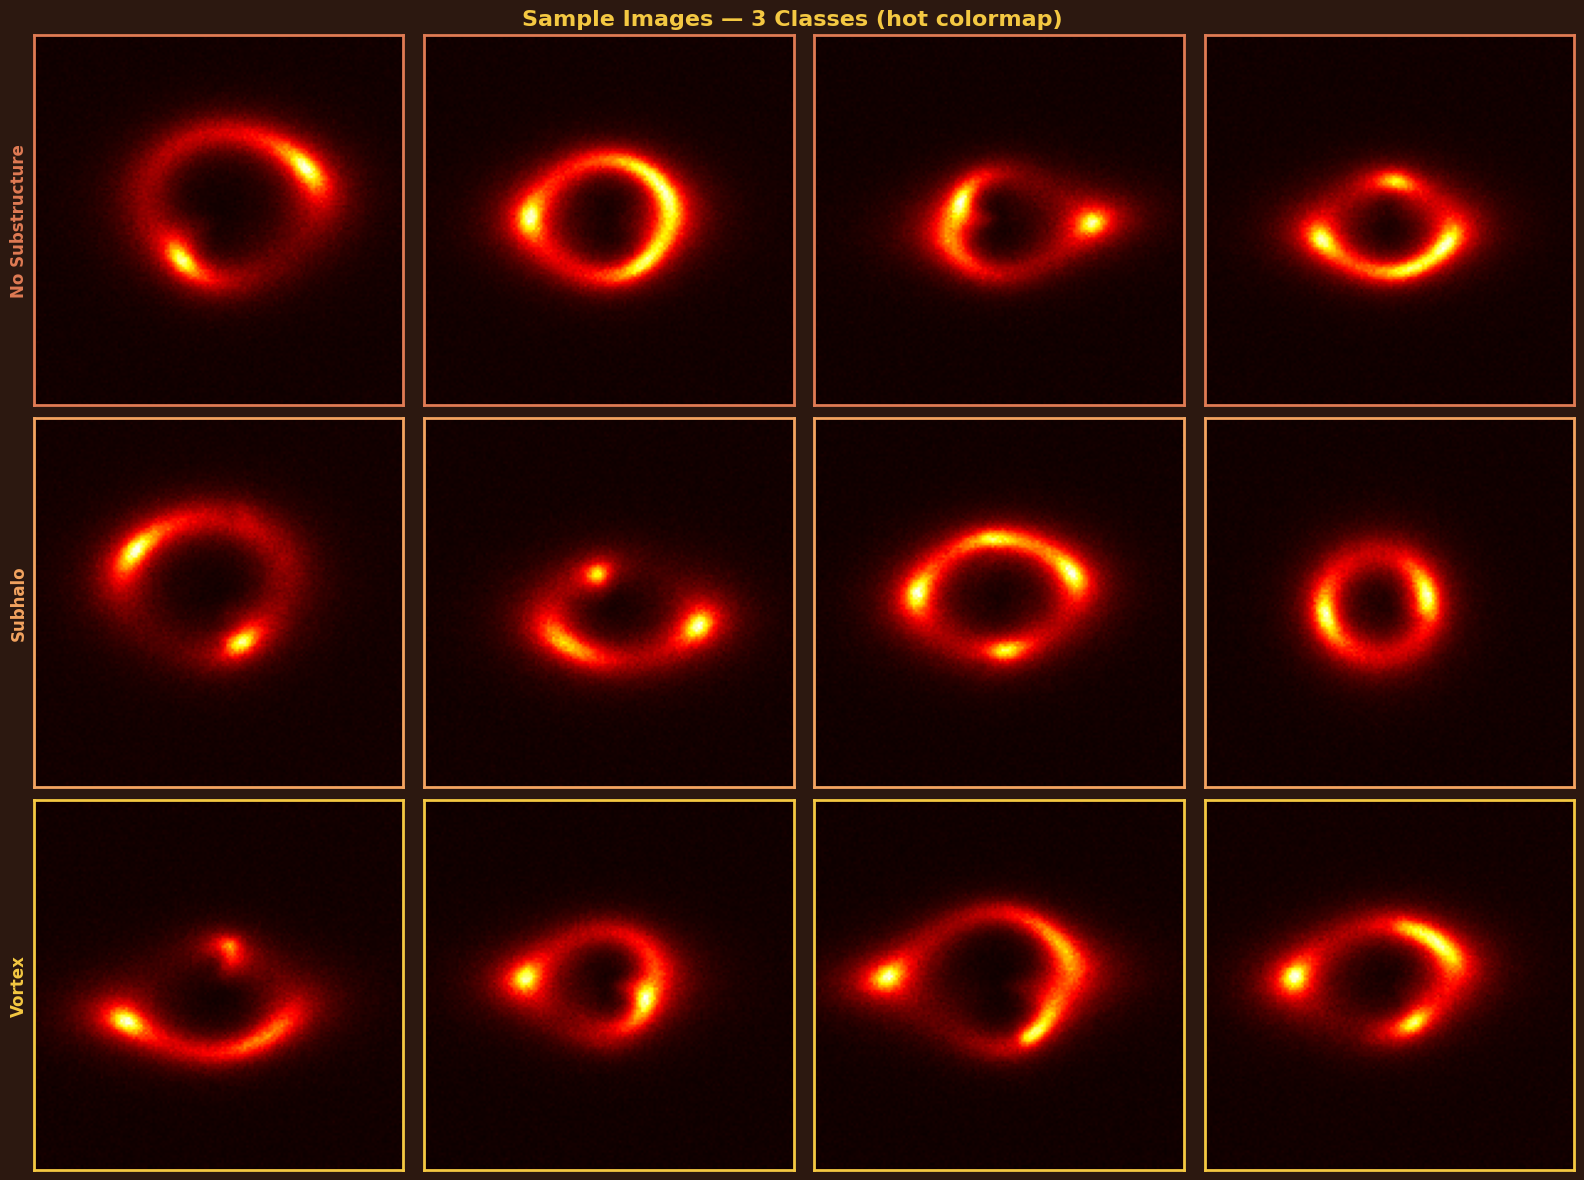

✅ Sample images displayed!


In [5]:
# Visualize sample images from each class
class_names = ['No Substructure', 'Subhalo', 'Vortex']
class_dirs  = ['no', 'sphere', 'vort']
colors      = ['#E07B54', '#F4A460', '#F4C842']

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
fig.patch.set_facecolor('#2C1810')

for row, (cls_dir, cls_name, color) in enumerate(
        zip(class_dirs, class_names, colors)):
    folder = os.path.join(train_dir, cls_dir)
    files  = sorted(os.listdir(folder))[:4]
    for col, fname in enumerate(files):
        img = np.load(os.path.join(folder, fname))
        if img.ndim == 3:
            img = img[0]  # take first channel
        ax = axes[row, col]
        ax.imshow(img, cmap='hot')
        ax.set_facecolor('#3D2314')
        ax.tick_params(left=False, bottom=False,
                       labelleft=False, labelbottom=False)
        for spine in ax.spines.values():
            spine.set_edgecolor(color)
            spine.set_linewidth(2)
        if col == 0:
            ax.set_ylabel(cls_name, color=color,
                          fontsize=12, fontweight='bold')

fig.suptitle('Sample Images — 3 Classes (hot colormap)',
             color='#F4C842', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sample_images.png', dpi=150,
            bbox_inches='tight', facecolor='#2C1810')
plt.show()
print('✅ Sample images displayed!')


## 2. Training Framework
A unified function to train any given model, evaluate it on the validation set, compute the Macro-Average AUC, and save the best weights.

In [6]:
def train_and_evaluate(model, model_name, num_epochs=20):
    print(f"\n{'='*50}")
    print(f"🚀 Training {model_name} for {num_epochs} Epochs")
    print(f"{'='*50}")

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

    best_auc = 0.0
    best_model_path = f'/content/best_model_{model_name.lower()}.pth'

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        start_time = time.time()

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        train_loss /= len(train_loader)

        # Validation
        model.eval()
        val_loss = 0.0
        all_labels, all_probs = [], []

        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

                probs = F.softmax(outputs, dim=1).cpu().numpy()
                all_probs.extend(probs)
                all_labels.extend(labels.cpu().numpy())

        val_loss /= len(val_loader)

        # Macro AUC
        labels_bin = label_binarize(all_labels, classes=[0, 1, 2])
        val_auc = roc_auc_score(labels_bin, np.array(all_probs), multi_class='ovr', average='macro')

        scheduler.step(val_auc)
        epoch_time = time.time() - start_time

        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), best_model_path)
            print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f} ⭐ BEST ({epoch_time:.0f}s)")
        else:
            print(f"Epoch {epoch+1:02d}/{num_epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val AUC: {val_auc:.4f} ({epoch_time:.0f}s)")

    print(f"✅ {model_name} Finished. Best Val AUC: {best_auc:.4f}")
    return best_auc, np.array(all_labels), np.array(all_probs), best_model_path

## 3. Model Initialization & Training
We will train **ResNet18** (Baseline) and **EfficientNet-B0** (Advanced).

In [7]:
NUM_EPOCHS = 20

# 1. ResNet18
resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = nn.Linear(resnet.fc.in_features, NUM_CLASSES)
resnet = resnet.to(device)

auc_res, labels_res, probs_res, path_res = train_and_evaluate(resnet, "ResNet18", num_epochs=NUM_EPOCHS)

# 2. EfficientNet-B0
effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
effnet.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(effnet.classifier[1].in_features, NUM_CLASSES)
)
effnet = effnet.to(device)

auc_eff, labels_eff, probs_eff, path_eff = train_and_evaluate(effnet, "EfficientNet-B0", num_epochs=NUM_EPOCHS)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 146MB/s]



🚀 Training ResNet18 for 20 Epochs
Epoch 01/20 | Train Loss: 1.0970 | Val Loss: 1.4997 | Val AUC: 0.6389 ⭐ BEST (66s)
Epoch 02/20 | Train Loss: 0.6728 | Val Loss: 0.5563 | Val AUC: 0.9204 ⭐ BEST (68s)
Epoch 03/20 | Train Loss: 0.4312 | Val Loss: 0.5492 | Val AUC: 0.9388 ⭐ BEST (66s)
Epoch 04/20 | Train Loss: 0.3484 | Val Loss: 0.4437 | Val AUC: 0.9598 ⭐ BEST (67s)
Epoch 05/20 | Train Loss: 0.3058 | Val Loss: 0.3785 | Val AUC: 0.9703 ⭐ BEST (65s)
Epoch 06/20 | Train Loss: 0.2871 | Val Loss: 0.3704 | Val AUC: 0.9696 (66s)
Epoch 07/20 | Train Loss: 0.2629 | Val Loss: 0.3109 | Val AUC: 0.9703 (64s)
Epoch 08/20 | Train Loss: 0.2500 | Val Loss: 0.2453 | Val AUC: 0.9806 ⭐ BEST (65s)
Epoch 09/20 | Train Loss: 0.2342 | Val Loss: 0.2537 | Val AUC: 0.9806 (63s)
Epoch 10/20 | Train Loss: 0.2309 | Val Loss: 0.2381 | Val AUC: 0.9828 ⭐ BEST (64s)
Epoch 11/20 | Train Loss: 0.2201 | Val Loss: 0.3480 | Val AUC: 0.9723 (63s)
Epoch 12/20 | Train Loss: 0.2099 | Val Loss: 0.2242 | Val AUC: 0.9838 ⭐ BEST (63

100%|██████████| 20.5M/20.5M [00:00<00:00, 196MB/s]



🚀 Training EfficientNet-B0 for 20 Epochs
Epoch 01/20 | Train Loss: 0.9852 | Val Loss: 0.7723 | Val AUC: 0.8298 ⭐ BEST (87s)
Epoch 02/20 | Train Loss: 0.6399 | Val Loss: 0.5304 | Val AUC: 0.9213 ⭐ BEST (88s)
Epoch 03/20 | Train Loss: 0.4803 | Val Loss: 0.5088 | Val AUC: 0.9384 ⭐ BEST (87s)
Epoch 04/20 | Train Loss: 0.3959 | Val Loss: 0.3756 | Val AUC: 0.9610 ⭐ BEST (87s)
Epoch 05/20 | Train Loss: 0.3368 | Val Loss: 0.3051 | Val AUC: 0.9725 ⭐ BEST (86s)
Epoch 06/20 | Train Loss: 0.2940 | Val Loss: 0.3491 | Val AUC: 0.9734 ⭐ BEST (86s)
Epoch 07/20 | Train Loss: 0.2693 | Val Loss: 0.2919 | Val AUC: 0.9799 ⭐ BEST (86s)
Epoch 08/20 | Train Loss: 0.2520 | Val Loss: 0.2510 | Val AUC: 0.9812 ⭐ BEST (86s)
Epoch 09/20 | Train Loss: 0.2306 | Val Loss: 0.2560 | Val AUC: 0.9832 ⭐ BEST (86s)
Epoch 10/20 | Train Loss: 0.2212 | Val Loss: 0.2096 | Val AUC: 0.9866 ⭐ BEST (86s)
Epoch 11/20 | Train Loss: 0.2094 | Val Loss: 0.2830 | Val AUC: 0.9834 (86s)
Epoch 12/20 | Train Loss: 0.2001 | Val Loss: 0.2150 

## 4. Model Comparison & Export
Generating the One-vs-Rest ROC Curve to compare the Macro-Average AUC of both models, and saving all artifacts to Google Drive.

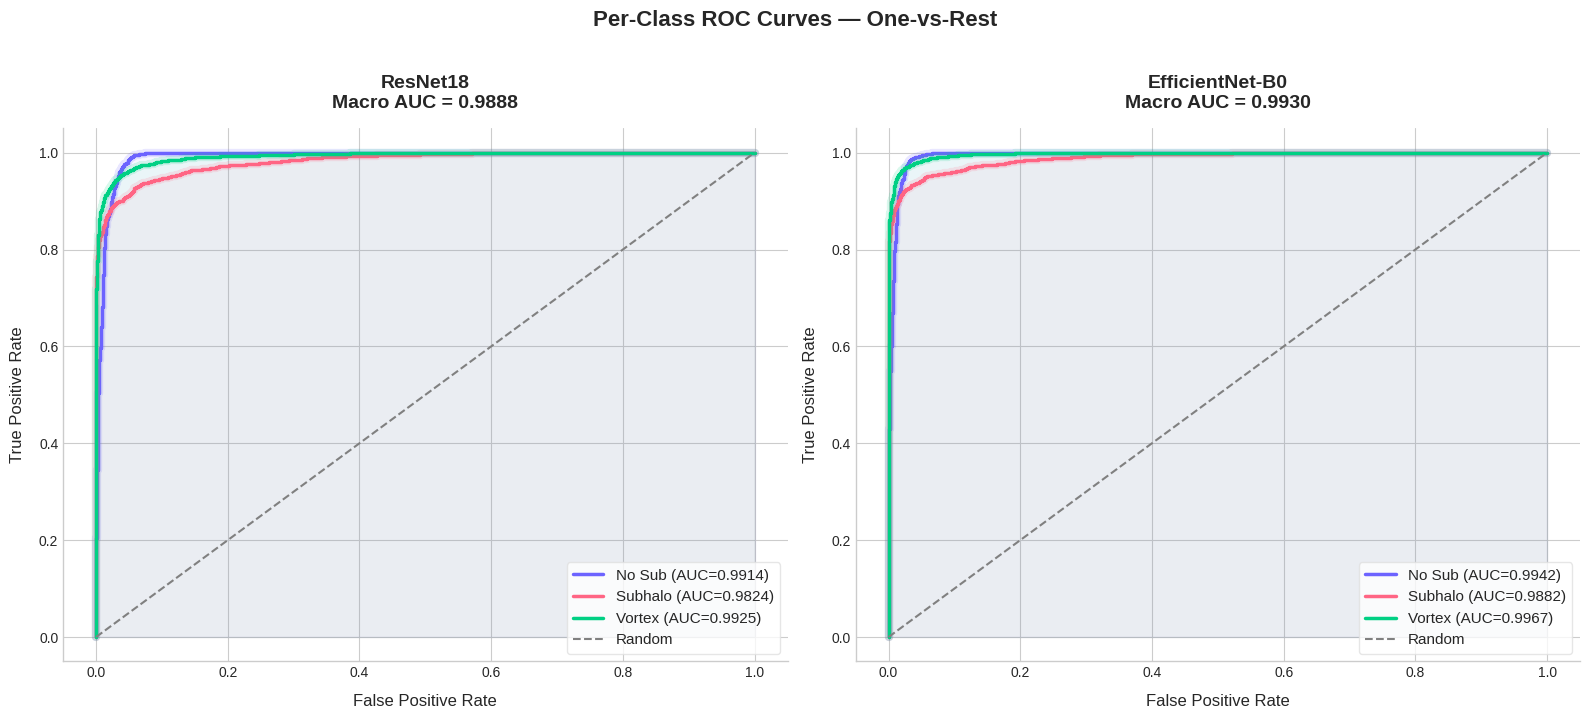

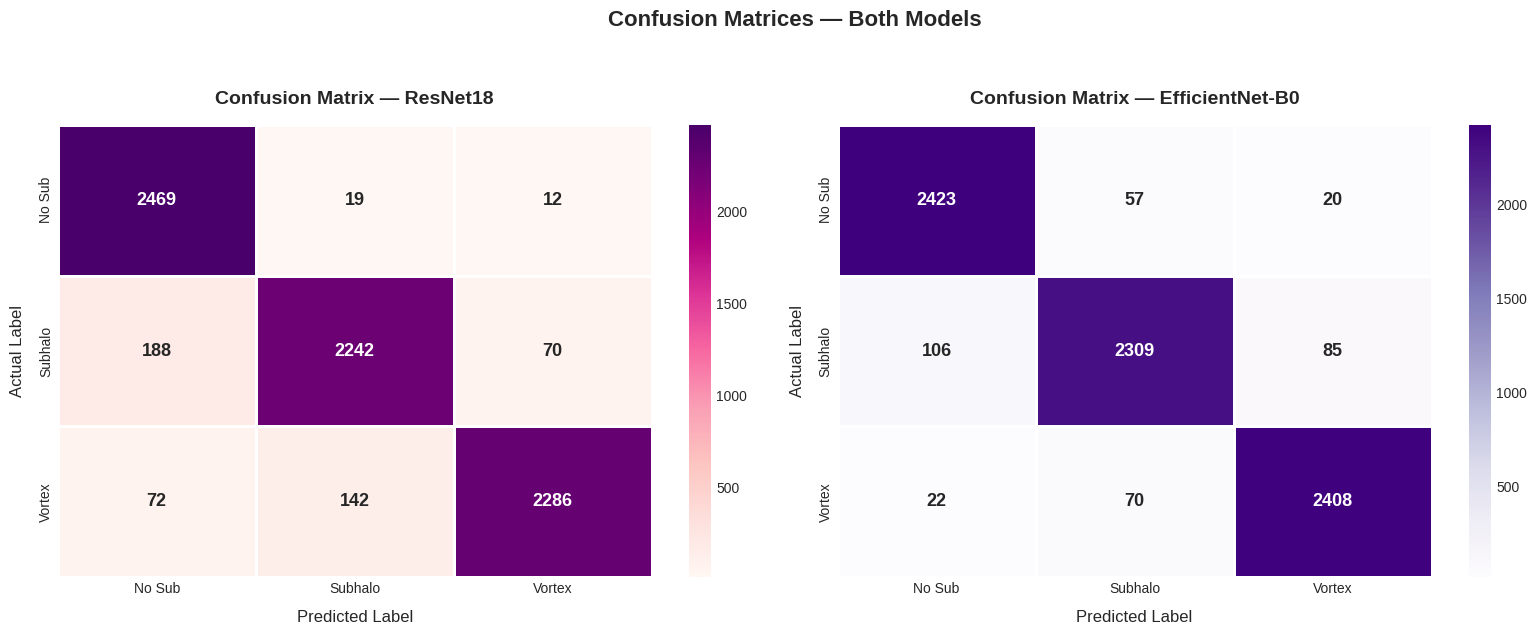


              Classification Report — ResNet18              
              precision    recall  f1-score   support

      No Sub     0.9047    0.9876    0.9443      2500
     Subhalo     0.9330    0.8968    0.9145      2500
      Vortex     0.9654    0.9144    0.9392      2500

    accuracy                         0.9329      7500
   macro avg     0.9344    0.9329    0.9327      7500
weighted avg     0.9344    0.9329    0.9327      7500


          Classification Report — EfficientNet-B0           
              precision    recall  f1-score   support

      No Sub     0.9498    0.9692    0.9594      2500
     Subhalo     0.9479    0.9236    0.9356      2500
      Vortex     0.9582    0.9632    0.9607      2500

    accuracy                         0.9520      7500
   macro avg     0.9520    0.9520    0.9519      7500
weighted avg     0.9520    0.9520    0.9519      7500



In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize

# توحيد الستايل العام ليكون نظيفاً ومريحاً للعين
plt.style.use('seaborn-v0_8-whitegrid')

CLASS_NAMES  = ['No Sub', 'Subhalo', 'Vortex']

# الألوان الثلاثة المتناسقة (البنفسجي، الوردي، الأخضر النعناعي)
colors_cls   = ['#6C63FF', '#FF6584', '#00D084']

models_eval = [
    ('ResNet18',        labels_res, probs_res),
    ('EfficientNet-B0', labels_eff, probs_eff),
]

# ── 1. Per-class ROC Curves ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

for ax, (name, lbls, prbs) in zip(axes, models_eval):
    ax.set_facecolor('white')
    y_bin = label_binarize(lbls, classes=[0, 1, 2])
    aucs_per_class = []

    for i, (cls_name, color) in enumerate(zip(CLASS_NAMES, colors_cls)):
        fpr, tpr, _ = roc_curve(y_bin[:, i], prbs[:, i])
        auc_score   = auc(fpr, tpr)
        aucs_per_class.append(auc_score)

        # تأثير التوهج (Glow effect) والخط الأساسي
        ax.plot(fpr, tpr, color=color, lw=6, alpha=0.15)
        ax.plot(fpr, tpr, color=color, lw=2.5,
                label=f'{cls_name} (AUC={auc_score:.4f})')
        ax.fill_between(fpr, tpr, alpha=0.05, color=color)

    ax.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5, label='Random')

    macro = np.mean(aucs_per_class)
    ax.set_title(f'{name}\nMacro AUC = {macro:.4f}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('False Positive Rate', fontsize=12, labelpad=10)
    ax.set_ylabel('True Positive Rate',  fontsize=12, labelpad=10)

    ax.legend(loc='lower right', fontsize=11, frameon=True, facecolor='white', edgecolor='#E0E0E0')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.spines['left'].set_color('#CCCCCC')

fig.suptitle('Per-Class ROC Curves — One-vs-Rest', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/roc_per_class_light.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ── 2. Confusion Matrices ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')

# استخدمت ألوان مختلفة لكل موديل لتمييزهما (وردي لـ ResNet وبنفسجي لـ EfficientNet)
cmaps = ['RdPu', 'Purples']

for ax, (name, lbls, prbs), cmap_choice in zip(axes, models_eval, cmaps):
    preds = np.argmax(prbs, axis=1)
    cm    = confusion_matrix(lbls, preds)

    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES,
                cmap=cmap_choice,
                linewidths=1, linecolor='white',
                annot_kws={"size": 13, "weight": "bold"})

    ax.set_title(f'Confusion Matrix — {name}', fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Predicted Label', fontsize=12, labelpad=10)
    ax.set_ylabel('Actual Label', fontsize=12, labelpad=10)

fig.suptitle('Confusion Matrices — Both Models', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('/content/confusion_matrices_light.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# ── 3. Classification Report ─────────────────────────────────────────────────
for name, lbls, prbs in models_eval:
    preds = np.argmax(prbs, axis=1)
    print(f'\n{"="*60}')
    print(f'{"Classification Report — " + name:^60}')
    print(f'{"="*60}')
    print(classification_report(
        lbls, preds,
        target_names=CLASS_NAMES,
        digits=4
    ))

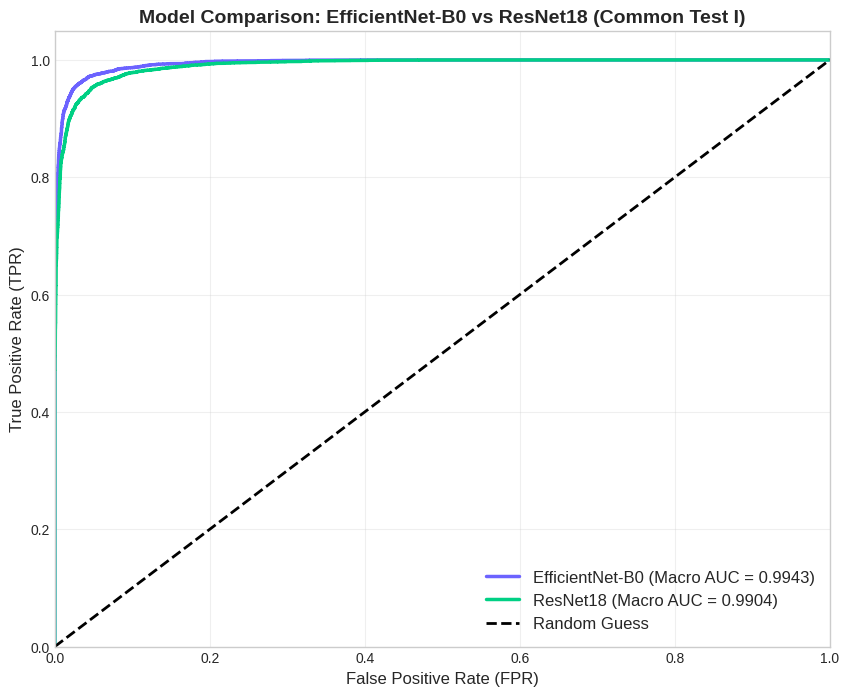

✅ All models and comparison plots successfully backed up to Google Drive!


In [16]:
from google.colab import files
# Calculate Macro ROC for ResNet18
y_val_bin = label_binarize(labels_res, classes=[0, 1, 2])
fpr_res, tpr_res, _ = roc_curve(y_val_bin.ravel(), probs_res.ravel())
mac_auc_res = auc(fpr_res, tpr_res)

# Calculate Macro ROC for EfficientNet-B0
fpr_eff, tpr_eff, _ = roc_curve(y_val_bin.ravel(), probs_eff.ravel())
mac_auc_eff = auc(fpr_eff, tpr_eff)

# Plot
plt.figure(figsize=(10, 8))
plt.plot(fpr_eff, tpr_eff, color='#6C63FF', lw=2.5, label=f'EfficientNet-B0 (Macro AUC = {mac_auc_eff:.4f})')
plt.plot(fpr_res, tpr_res, color='#00D084', lw=2.5, label=f'ResNet18 (Macro AUC = {mac_auc_res:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('Model Comparison: EfficientNet-B0 vs ResNet18 (Common Test I)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, alpha=0.3)

plot_path = '/content/model_comparison_common_test.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()

# Backup to Google Drive
save_dir = '/content/drive/MyDrive/Colab Notebooks/GSoC2026/CommonTestI'
os.makedirs(save_dir, exist_ok=True)

shutil.copy(path_res, f'{save_dir}/best_model_resnet18.pth')
shutil.copy(path_eff, f'{save_dir}/best_model_efficientnet_b0.pth')
shutil.copy(plot_path, f'{save_dir}/model_comparison_common_test.png')
shutil.copy('/content/roc_per_class_light.png', f'{save_dir}/roc_per_class_light.png')
shutil.copy('/content/confusion_matrices_light.png', f'{save_dir}/confusion_matrices_light.png')

print("✅ All models and comparison plots successfully backed up to Google Drive!")